# Mortalidade por Violência contra Mulheres no Brasil (2015–2021)

Análise exploratória da mortalidade feminina por agressão no Brasil, utilizando dados oficiais do DATASUS/SIM e estimativas populacionais do IBGE.

**Recorte:**
- Causas: CID-10 X85 a Y09 (agressões)
- Sexo: feminino
- Período: 2015 a 2021
- Abrangência: 27 unidades federativas

## Configuração do Ambiente e Definições de Domínio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Função reutilizável para padronizar o cálculo de mortalidade por 100 mil habitantes

def calcular_taxa_100k(obitos, populacao):
    return ((obitos / populacao) * 100000).round(2)

In [3]:
# CÉLULA 3
# Tabela de domínio (Lookup Table) para conversão do código numérico territorial do IBGE
#
codigo_estado = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO", "21": "MA", "22": "PI", "23": "CE",
    "24": "RN", "25": "PB", "26": "PE", "27": "AL", "28": "SE",
    "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT",
    "52": "GO", "53": "DF"
}


## Coleta de dados

Os dados de óbitos foram obtidos diretamente do TABNET/DATASUS — a fonte oficial do Ministério da Saúde. Os dados populacionais foram obtidos via API do IBGE (SIDRA, Tabela 6579 — estimativas intercensitárias por UF).

In [4]:
# Endpoint da API de Agregados do IBGE (Tabela 6579, Variável 9324 - População feminina residente)
# Parâmetros: períodos de 2015 a 2022, nível territorial 3 (N3[all] = todas as UFs)

url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2015|2016|2017|2018|2019|2020|2021/variaveis/9324?localidades=N3[all]"


response = requests.get(url)
dados = response.json()

print(response.status_code)


200


In [5]:

registros = []

# Iteração aninhada para extrair a população por Estado e por Ano da estrutura complexa do JSON
for serie in dados[0]["resultados"][0]["series"]:
    estado = codigo_estado[serie["localidade"]["id"]]
    for ano, populacao in serie["serie"].items():
        registros.append({
            "ESTADO": estado,
            "ANO": int(ano),
            "POPULACAO": int(populacao)
        })

populacao_df = pd.DataFrame(registros)
print(populacao_df.shape)
print(populacao_df.head())


(189, 3)
  ESTADO   ANO  POPULACAO
0     RO  2015    1768204
1     RO  2016    1787279
2     RO  2017    1805788
3     RO  2018    1757589
4     RO  2019    1777225


## Preparação de dados

Os dados de óbitos chegam no formato largo (um ano por coluna) e precisam ser transformados para o formato longo (uma linha por estado/ano) antes do merge com a população.

In [6]:
df_tabnet = pd.read_csv("obitos_tabnet_2015_2021.csv").dropna()
print(df_tabnet.head(5))
print(df_tabnet.shape)


        ESTADO   2015   2016   2017   2018   2019   2020   2021
0  11 Rondônia   63.0   54.0   62.0   42.0   43.0   54.0   54.0
1      12 Acre   19.0   23.0   34.0   35.0   32.0   27.0   28.0
2  13 Amazonas  115.0  116.0  115.0  127.0  118.0   85.0  135.0
3   14 Roraima   29.0   25.0   27.0   53.0   33.0   35.0   20.0
4      15 Pará  261.0  294.0  310.0  323.0  232.0  192.0  207.0
(27, 8)


In [7]:
print(df_tabnet)

                    ESTADO   2015   2016   2017   2018   2019   2020   2021
0              11 Rondônia   63.0   54.0   62.0   42.0   43.0   54.0   54.0
1                  12 Acre   19.0   23.0   34.0   35.0   32.0   27.0   28.0
2              13 Amazonas  115.0  116.0  115.0  127.0  118.0   85.0  135.0
3               14 Roraima   29.0   25.0   27.0   53.0   33.0   35.0   20.0
4                  15 Pará  261.0  294.0  310.0  323.0  232.0  192.0  207.0
5                 16 Amapá   18.0   17.0   27.0   15.0   17.0   22.0   19.0
6             17 Tocantins   48.0   45.0   38.0   47.0   36.0   35.0   39.0
7              21 Maranhão  148.0  159.0  127.0  122.0  114.0  140.0  131.0
8                 22 Piauí   67.0   50.0   52.0   52.0   47.0   54.0   68.0
9                 23 Ceará  254.0  218.0  374.0  475.0  220.0  318.0  335.0
10  24 Rio Grande do Norte   91.0  100.0  148.0  102.0   98.0   81.0   70.0
11              25 Paraíba  111.0  107.0   88.0   82.0   72.0   94.0   83.0
12          

In [8]:
# Extrai os 2 primeiros caracteres do código IBGE e mapeia para sigla
df_tabnet["ESTADO"] = df_tabnet["ESTADO"].str[:2].map(codigo_estado)
print(df_tabnet["ESTADO"].head())


0    RO
1    AC
2    AM
3    RR
4    PA
Name: ESTADO, dtype: object


In [9]:
# Transforma formato largo (ano por coluna) em longo (uma linha por estado/ano)
obitos_agrupados = df_tabnet.melt(
    id_vars="ESTADO",
    var_name="ANO",
    value_name="OBITOS"
)

# melt retorna ANO como string e OBITOS como float — conversão necessária para o merge
obitos_agrupados["ANO"] = obitos_agrupados["ANO"].astype(int)
obitos_agrupados["OBITOS"] = obitos_agrupados["OBITOS"].astype(int)

print(obitos_agrupados.shape)
print(obitos_agrupados.head())


(189, 3)
  ESTADO   ANO  OBITOS
0     RO  2015      63
1     AC  2015      19
2     AM  2015     115
3     RR  2015      29
4     PA  2015     261


In [10]:
# Inner join — exclui automaticamente combinações sem dados nos dois lados
tabela_unificada = pd.merge(obitos_agrupados, populacao_df, on=["ESTADO", "ANO"], how="inner")


In [11]:
tabela_unificada["TAXA_POR_100K"] = calcular_taxa_100k(
    tabela_unificada["OBITOS"],
    tabela_unificada["POPULACAO"]
)


## Análises e visualizações

As visualizações respondem três perguntas:
1. Como a taxa de mortalidade evoluiu no Brasil ao longo do período?
2. Quais os estados concentram as maiores taxas históricas?
3. Quais os estados melhoraram ou pioraram entre 2015 e 2021?

In [12]:
# Soma valores brutos antes de calcular a taxa — agregar taxas diretamente é matematicamente incorreto
evolucao_brasil = (
    tabela_unificada.groupby("ANO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
) 
print(evolucao_brasil)


    ANO  OBITOS  POPULACAO
0  2015    4616  204450049
1  2016    4635  206081432
2  2017    4928  207660929
3  2018    4512  208494900
4  2019    3728  210147125
5  2020    3822  211755692
6  2021    3844  213317639


In [13]:
evolucao_brasil["TAXA_BRASIL"] = calcular_taxa_100k(
    evolucao_brasil["OBITOS"],
    evolucao_brasil["POPULACAO"]
)


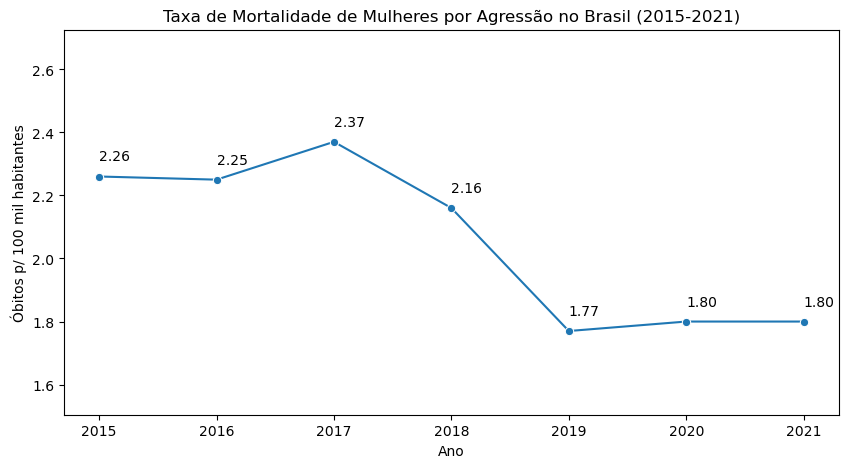

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha = sns.lineplot(
    data=evolucao_brasil, 
    x="ANO",
    y="TAXA_BRASIL",
    marker = "o",
    ax=ax,
)

grafico_linha.set(
    title="Taxa de Mortalidade de Mulheres por Agressão no Brasil (2015-2021)",
    xlabel="Ano", 
    ylabel="Óbitos p/ 100 mil habitantes",
    ylim=(evolucao_brasil["TAXA_BRASIL"].min() * 0.85, evolucao_brasil["TAXA_BRASIL"].max() * 1.15)
)

for indice, linha in evolucao_brasil.iterrows():

    grafico_linha.text(
        x=linha["ANO"],
        y=linha["TAXA_BRASIL"]
        + 0.05,
        s=f'{linha["TAXA_BRASIL"]:.2f}',
    )

fig.savefig(
    "taxa_mortalidade_brasil.png",
    dpi=300,
    bbox_inches="tight",
)
    
plt.show()


In [15]:
ranking_estado_historico = (
    tabela_unificada.groupby("ESTADO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
)

ranking_estado_historico["TAXA_ESTADO"] = calcular_taxa_100k(
    ranking_estado_historico["OBITOS"],
    ranking_estado_historico["POPULACAO"]
)

ranking_estado_historico = ranking_estado_historico.sort_values(
    by="TAXA_ESTADO", ascending=False
)

ranking_estado_historico


,ESTADO,OBITOS,POPULACAO,TAXA_ESTADO
21,RR,222,4008753,5.54
5,CE,2194,63523992,3.45
0,AC,198,6002365,3.30
13,PA,1819,59398696,3.06
20,RO,372,12507823,2.97
7,ES,819,28083562,2.92
8,GO,1408,48344952,2.91
4,BA,3026,105425946,2.87
2,AM,811,28706534,2.83
19,RN,690,24505107,2.82


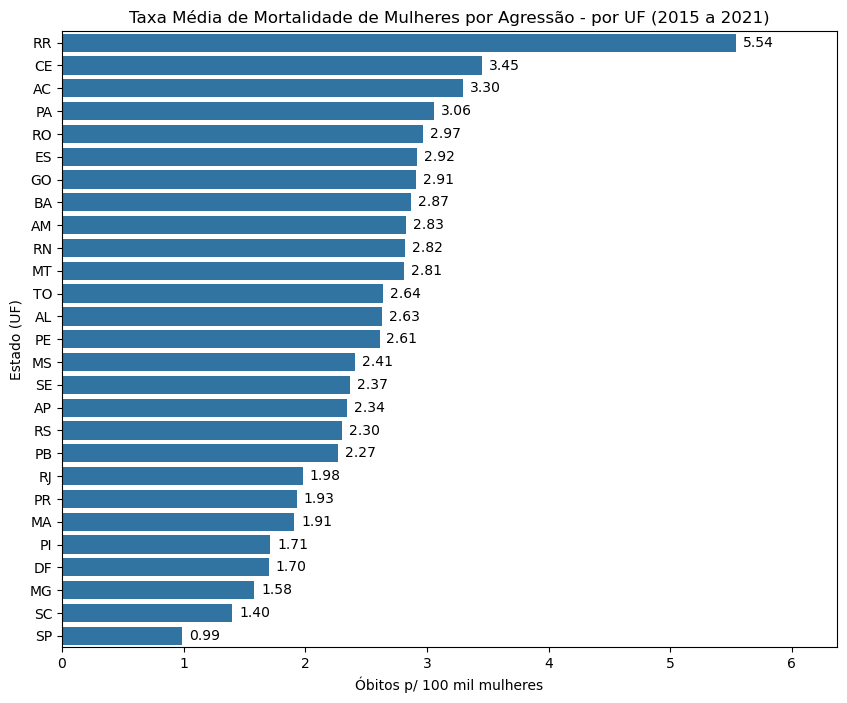

In [16]:
fig, ax = plt.subplots(figsize=(10,8))

grafico_barras = sns.barplot(
    data=ranking_estado_historico,
    x="TAXA_ESTADO",
    y="ESTADO",
    ax=ax
)

grafico_barras.set(
    title="Taxa Média de Mortalidade de Mulheres por Agressão - por UF (2015 a 2021)",
    xlabel="Óbitos p/ 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(0, ranking_estado_historico["TAXA_ESTADO"].max() * 1.15)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=5
)

fig.savefig("taxa_mortalidade_estados.png", dpi=300, bbox_inches="tight")

plt.show()


In [17]:
# Variação entre pontos extremos do período — não captura oscilações intermediárias
df_pivot = tabela_unificada.pivot(index="ESTADO", columns="ANO", values="TAXA_POR_100K")
df_pivot["VARIACAO_PERCENTUAL"] = (
    ((df_pivot[2021] - df_pivot[2015]) / df_pivot[2015]) * 100
)
df_pivot["TENDENCIA"] = df_pivot["VARIACAO_PERCENTUAL"].apply(lambda x: "Piora (Aumento)" if x > 0  else "Melhora (Queda)")
tabela_variacao = df_pivot.sort_values(by="VARIACAO_PERCENTUAL", ascending=False)


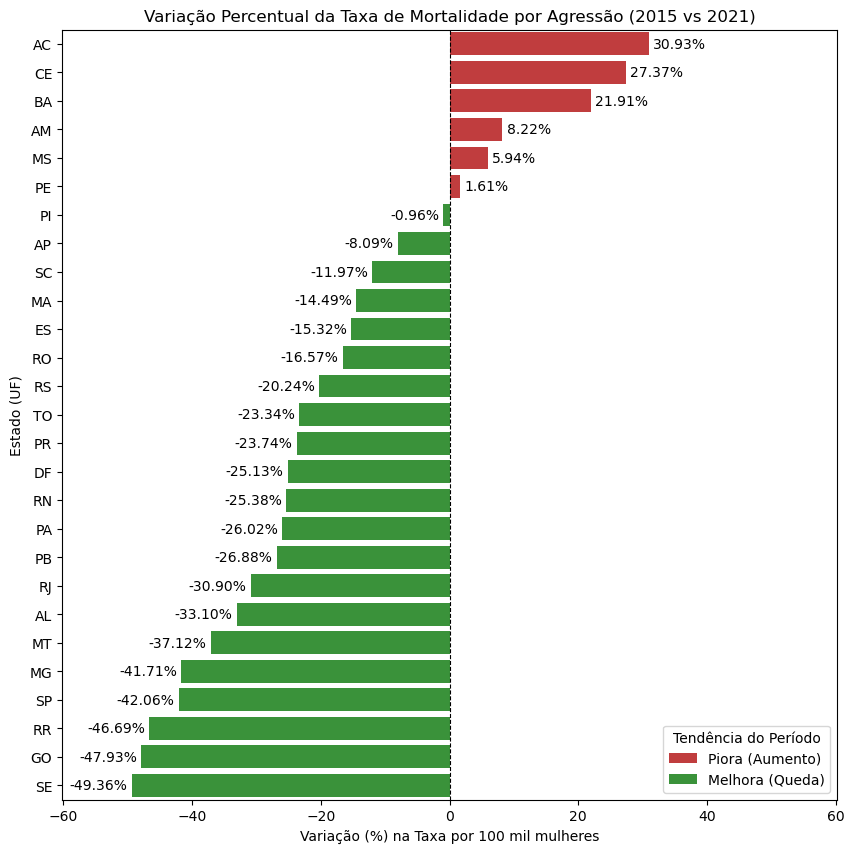

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

grafico_variacao = sns.barplot(
    data=tabela_variacao,
    x="VARIACAO_PERCENTUAL",
    y="ESTADO",
    hue="TENDENCIA",
    ax=ax,
    palette={
        "Piora (Aumento)": "#d62728",
        "Melhora (Queda)": "#2ca02c"
    }
)

limite = max(
    abs(tabela_variacao["VARIACAO_PERCENTUAL"].min()),
    abs(tabela_variacao["VARIACAO_PERCENTUAL"].max())
) * 1.22

grafico_variacao.set(
    title="Variação Percentual da Taxa de Mortalidade por Agressão (2015 vs 2021)",
    xlabel="Variação (%) na Taxa por 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(-limite, limite)    
)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.legend(title="Tendência do Período", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

fig.savefig(
    "variacao_mortalidade_uf_2015_2021.png", dpi=300, bbox_inches="tight"
)

plt.show()


---

## 5. Síntese Analítica e Conclusões Executivas

A modelagem de dados da série histórica revela discrepâncias relevantes entre o comportamento da média nacional e a realidade regional da violência letal contra a mulher no Brasil.

### 1. Descolamento Nacional vs. Estadual
* O indicador consolidado do Brasil sugere uma transição favorável de queda na mortalidade feminina por agressão no intervalo analisado.
* **Redução majoritária:** Das 27 Unidades da Federação, **21 estados (77,7%)** registraram queda em suas taxas. O topo da tabela de melhorias é liderado por **Sergipe (-49,36%)**, **Goiás (-47,93%)** e **Roraima (-46,69%)**, que reduziram praticamente pela metade seus índices letais.

### 2. Identificação de Bolsões Críticos
* Em sentido oposto à média do país, **6 estados (22,3%)** apresentaram **crescimento percentual** na mortalidade feminina por agressão entre 2015 e 2021.
* A deterioração do indicador concentra-se majoritariamente em estados das regiões Norte e Nordeste, com as maiores variações sendo:
  * **Acre (AC):** +30,93%
  * **Ceará (CE):** +27,37%
  * **Bahia (BA):** +21,91%
  * **Amazonas (AM):** +8,22%

### 3. Considerações para Tomada de Decisão
Os dados evidenciam que abordagens padronizadas em nível federal são insuficientes para tratar a violência contra a mulher, visto que a média nacional em queda mascara o agravamento severo do cenário em estados específicos. A alocação de recursos públicos, estratégias preventivas e inteligência policial devem ser direcionadas com urgência para o recrudescimento observado em estados como Acre, Ceará e Bahia.

In [19]:
df_ml_base = tabela_variacao.reset_index()


In [20]:
df_ml_base = df_ml_base[["ESTADO", 2015, 2021]]
print(df_ml_base.head())


ANO ESTADO  2015  2021
0       AC  2.36  3.09
1       CE  2.85  3.63
2       BA  2.51  3.06
3       AM  2.92  3.16
4       MS  2.19  2.32


In [21]:
df_ml = pd.merge(df_ml_base, ranking_estado_historico[["ESTADO", "TAXA_ESTADO"]], on="ESTADO")
df_ml = df_ml.rename(columns={2015: "TAXA_2015", 2021: "TAXA_2021"})
print(df_ml.head())


  ESTADO  TAXA_2015  TAXA_2021  TAXA_ESTADO
0     AC       2.36       3.09         3.30
1     CE       2.85       3.63         3.45
2     BA       2.51       3.06         2.87
3     AM       2.92       3.16         2.83
4     MS       2.19       2.32         2.41


In [22]:
features = df_ml[["TAXA_ESTADO", "TAXA_2015", "TAXA_2021"]]
print(features.head())


   TAXA_ESTADO  TAXA_2015  TAXA_2021
0         3.30       2.36       3.09
1         3.45       2.85       3.63
2         2.87       2.51       3.06
3         2.83       2.92       3.16
4         2.41       2.19       2.32


In [23]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print(features_scaled)


[[ 0.9248762  -0.42908666  1.29252741]
 [ 1.10452841  0.13916324  2.07675753]
 [ 0.40987319 -0.25513261  1.24895907]
 [ 0.36196594  0.2203418   1.39418687]
 [-0.14106025 -0.62623458  0.17427336]
 [ 0.09847603 -0.27832648  0.47925174]
 [-0.97943724 -0.74220395 -0.18879614]
 [-0.22489795 -0.4406836  -0.05809112]
 [-1.35071847 -1.51919871 -1.37966409]
 [-0.73990096 -0.68421927 -0.53734286]
 [ 0.46975726  0.99733656  1.21991351]
 [ 0.52964133  0.96254575  1.11825405]
 [-0.27280521 -0.24353567 -0.27593282]
 [ 0.13440647  0.51026522  0.33402394]
 [-0.71594733 -0.62623458 -0.76970733]
 [-0.99141405 -0.85817332 -1.03111737]
 [ 0.34998912 -0.10437243 -0.33402394]
 [ 0.63743266  0.53345909  0.23236448]
 [-0.30873565  0.06958162 -0.23236448]
 [-0.65606326 -0.46387747 -0.85684401]
 [ 0.12242965  0.1275663  -0.4356834 ]
 [ 0.33801231  1.02053043  0.10165946]
 [-1.13513582 -0.85817332 -1.51036911]
 [-1.84176785 -1.7047497  -2.13484865]
 [ 3.60768254  3.49067796  1.24895907]
 [ 0.45778045  1.31045385

In [24]:
inertias = []
for k in range(1, 11):
     kmeans = KMeans(n_clusters=k, n_init=10)
     kmeans.fit(features_scaled)
     inertias.append(kmeans.inertia_)

print(inertias)



[81.0, 42.239544119892926, 24.450438545600537, 14.479435957594406, 10.325854091113401, 7.526045107717052, 6.097665397902797, 4.856737102905848, 4.145882129519736, 3.2521592875162]


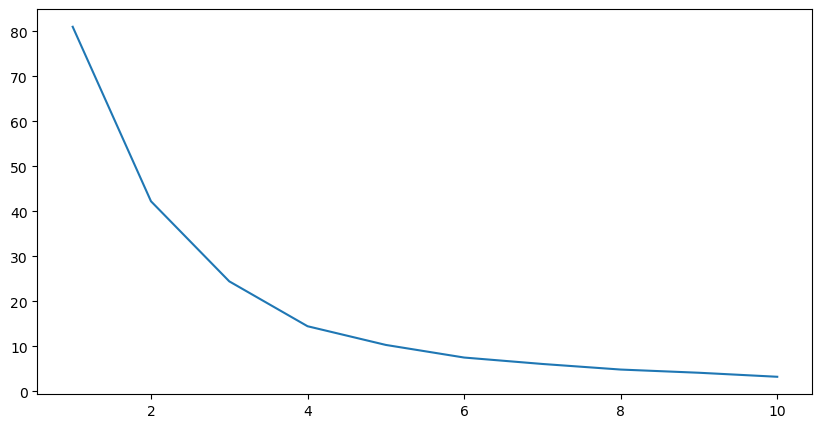

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha_kmeans = sns.lineplot(
    x=range(1,11),
    y=inertias,
    ax=ax
)
plt.show()


In [26]:
kmeans_final = KMeans(n_clusters=5, n_init=10, random_state=42).fit(features_scaled)
df_ml["cluster"] = kmeans_final.labels_
print(df_ml[["ESTADO", "cluster"]].sort_values("cluster"))

   ESTADO  cluster
26     SE        0
20     AL        0
19     RJ        0
18     PB        0
4      MS        0
5      PE        0
6      PI        0
7      AP        0
16     RN        0
9      MA        0
14     PR        0
12     RS        0
0      AC        1
3      AM        1
2      BA        1
1      CE        1
25     GO        2
10     ES        2
17     PA        2
21     MT        2
11     RO        2
13     TO        2
24     RR        3
15     DF        4
8      SC        4
22     MG        4
23     SP        4


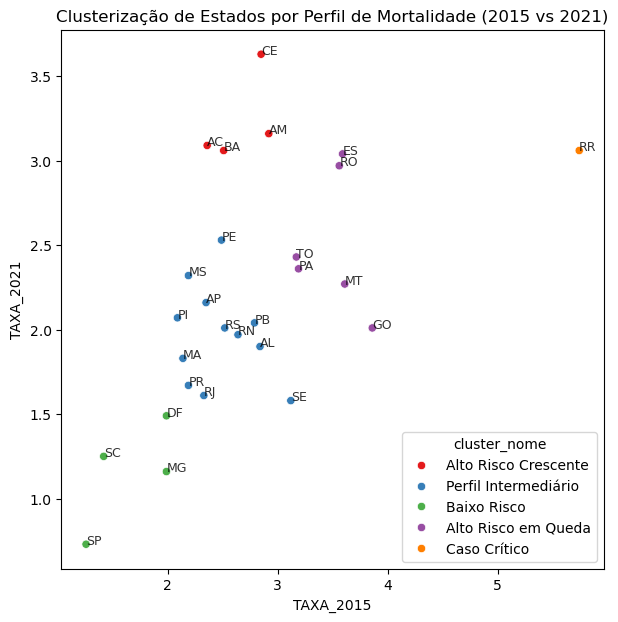

In [28]:
nomes_clusters = {
    0: "Perfil Intermediário",
    1: "Alto Risco Crescente",
    2: "Alto Risco em Queda",
    3: "Caso Crítico",
    4: "Baixo Risco"
}

df_ml["cluster_nome"] = df_ml["cluster"].map(nomes_clusters)

fig, ax = plt.subplots(figsize=(7, 7))
scatter_plot = sns.scatterplot(
    data=df_ml,
    x="TAXA_2015",
    y="TAXA_2021",
    hue="cluster_nome",
    palette="Set1"
)

for indice, linha in df_ml.iterrows():

    scatter_plot.text(
        x=linha["TAXA_2015"],
        y=linha["TAXA_2021"],
        s=linha["ESTADO"],
        fontsize=9,
        alpha=0.8,
    )

scatter_plot.set(title="Clusterização de Estados por Perfil de Mortalidade (2015 vs 2021)")

fig.savefig("outputs/cluster_estados.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
perfil_clusters = (
    df_ml.groupby("cluster_nome")[["TAXA_2015", "TAXA_2021", "TAXA_ESTADO"]]
    .mean()
)
print(perfil_clusters.head())

                      TAXA_2015  TAXA_2021  TAXA_ESTADO
cluster_nome                                           
Alto Risco Crescente   2.660000   3.235000     3.112500
Alto Risco em Queda    3.496667   2.513333     2.885000
Baixo Risco            1.665000   1.157500     1.417500
Caso Crítico           5.740000   3.060000     5.540000
Perfil Intermediário   2.474167   1.974167     2.273333
